<a href="https://colab.research.google.com/github/kanepeters/lis4693/blob/main/lab-5/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing and importing packages.

In [ ]:
!pip install gensim
!pip install pyldavis
!pip install nltk
import nltk
nltk.download('stopwords')

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load the dataset.

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/kanepeters/lis4693/refs/heads/main/lab-5/lens-export.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

The dataset contains 1000 records of bibliographic metadata from Lens.org based upon a search of scholarly articles containing the phrase "social media." The records in the dataset contain fields associated with each article, such as the title, the date published, as well as the abstract in some cases. These fields are not necessarily non-empty. I've selected this dataset because I feel that research into social media is something that has experienced a boom due to the advent of the COVID-19 pandemic in 2020. There is a sentiment that this event engendered increased social media use, especially in the youth.

The results of the search query can be seen here: https://www.lens.org/lens/search/scholar/list?q=(social%20media)&p=0&n=10&s=date_published&d=%2B&f=false&e=false&l=en&authorField=author&dateFilterField=publishedYear&orderBy=%2Bdate_published&presentation=false&preview=true&stemmed=true&useAuthorId=false


Import the pandas library and convert the response into a DataFrame. Then, display the first 10 rows of the dataset.

In [ ]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head(10))

               Lens ID                                              Title  \
0  000-043-933-900-503          Guerrilla Media: Interactive Social Media   
1  000-075-704-381-195                       SOCIAL MEDIA FOR SOCIAL GOOD   
2  000-142-696-903-789  THE EFFECT OF SOCIAL MEDIA CUSTOMER ENGAGEMENT...   
3  000-847-348-082-240  Social Media Intelligence: Building Social Med...   
4  000-916-330-196-051  To Be or Not to Be on Social Media: How Social...   
5  001-121-360-345-684           Social work and social media in practice   
6  001-456-744-003-573            Social media is more social than media.   
7  001-910-253-865-467                   Social movement and social media   
8  002-457-114-503-486  LawLibGuides: SOCIAL MEDIA AND THE LAW: Social...   
9  002-505-962-741-317             Sport, Digital Media, and Social Media   

  Date Published  Publication Year Publication Type  \
0            NaN            2016.0     book chapter   
1            NaN            2012.0        

The "Abstract" column should be considered for topic modelling, as this column provides more detailed information related to each article. It should be noted, however, that the abstract is not available for all the records in the dataset.

In [ ]:
# Compile all the abstracts into a list
docs = df.Abstract.tolist()
# Abstract in the first record (index 0)
print(docs[0])
# No abstract in index 1; value comes out as NaN.
print(docs[1])

In the convergence culture we are witnessing the rise of social or consumer-generated media—social networks, social blogs, weblogs, podcasts, pictures and videos—that increase communication intensity between people. Key properties of social media, such as frequency, immediacy, permanence and interactivity, should also be the key properties of traditional media—television and newspapers. Unfortunately this is rarely the case.
nan


Load stopwords.

In [ ]:
stop_words = stopwords.words('english')

Define function for document preprocessing.

In [ ]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

## Adding custom stopwords
# Include 'social' and 'media' due to redundancy in the abstract field.
custom_stopwords = ['social', 'media', '1', '2021']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['social', 'media', '1', '2021']


Perform preprocessing on all the records in the dataset; create the bag-of-words corpus. Test preprocessing using the first record in the dataset (index 0).

In [ ]:
# Replace NaN values in the Abstract column with empty strings.
docs = df.Abstract.fillna('').tolist()

cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
In the convergence culture we are witnessing the rise of social or consumer-generated media—social networks, social blogs, weblogs, podcasts, pictures and videos—that increase communication intensity between people. Key properties of social media, such as frequency, immediacy, permanence and interactivity, should also be the key properties of traditional media—television and newspapers. Unfortunately this is rarely the case.

Cleaned document with custom stopwords:
['convergence', 'culture', 'witnessing', 'rise', 'consumergenerated', 'media—social', 'networks', 'blogs', 'weblogs', 'podcasts', 'pictures', 'videos—that', 'increase', 'communication', 'intensity', 'people', 'key', 'properties', 'frequency', 'immediacy', 'permanence', 'interactivity', 'also', 'key', 'properties', 'traditional', 'media—television', 'newspapers', 'unfortunately', 'rarely', 'case']


Train an LDA model for 10 topics.

In [ ]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)
topics = lda_model.get_document_topics(corpus)
len(topics)
for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

(0, 0.971851110458374)


[10 topics]: Print the top 5 top words for each topic.

In [ ]:
for topic in topics[0]:
    terms = lda_model.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(0, 0.971851110458374)
89 use
128 chapter
357 internet
3 communication
264 new



Train an LDA model for 20 topics.

In [ ]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)
topics = lda_model.get_document_topics(corpus)
len(topics)
for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

(16, 0.9703054428100586)


[20 topics]: Print the top 5 words for each topic.

In [ ]:
for topic in topics[0]:
    terms = lda_model.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(16, 0.9703054428100586)
89 use
15 networks
0 also
408 health
304 facebook



Prepare the data for plotting by converting the topic words and probabilities into a pandas DataFrame.

In [ ]:
topic_data = []
target_topic_ids = [4, 9, 14, 19]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID           Word  Probability
0         4       research     0.008525
1         4  communication     0.005434
2         4            new     0.005228
3         4        alcohol     0.005135
4         4      different     0.005052


Visualize the topic results using bar graph for topics 5, 10, 15, 20.

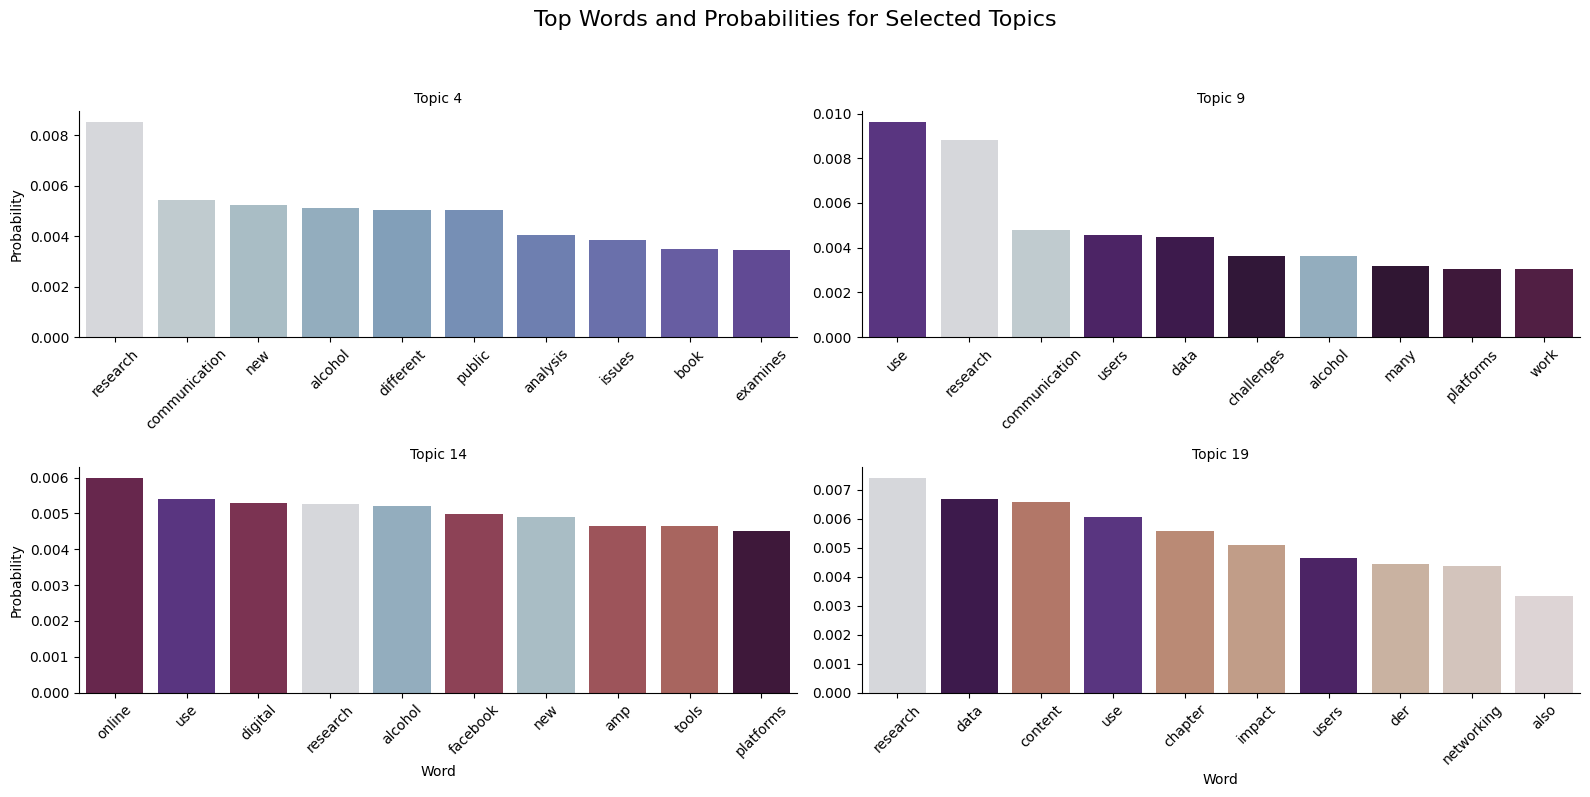

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Topic 5: Communication Research
Topic 10: Research into Social Media Use
Topic 15: Online
Topic 20: Data Research

"Research" seems to be the most distinct for topic 5 in particular. It also overlaps promintently for topics 10, 15, and 20. "Use" also seems to overlap significantly. Keywords such as these seem to be logical in the sense that the articles would likely be dealing with research into social media use; in other words, the researchers want to learn about the habits of social media users.

"Alcohol" also seems to stand out with respect to overlapping. That on its own may warrant further investigation; it may suggest that there is research being conducted that connects social media and alcohol use.

**What went well?**

Producing the visualization for the topic results seemed to give a more understanable picture of what the model determined with respect to the dataset.

**What did not go well or what challenges you encountered?**

I had to introduce 'social' and 'media' as custom stopwords because they were overrepresented as topic candidates; in other words, they were overly represented in the abstract fields. Since the dataset I chose was based on a query of social media articles, this would have been not useful for an analysis of the topics. Having "social media" itself as a topic would be highly redundant.

**In what ways could topic modeling be integrated into your current or future professional or research work?**

Topic modeling seems particularly useful when dealing with a large amount of documents. Once a certain threshold in terms of quantity is reached, it becomes impractical for a single person to parse some sort of meaning from all of the information. Topic modeling in this case allows someone to glean some idea of what a large amount of documents are covering collectively.